#### Stats post-processing

This notebook performs the post-processing of the statistical data. More specifically, it goes through the following steps:
1. reads the `stats1` and `stats2` files of each block and plots any variable
2. computes the total pressure field across the domain, the measurement planes and the mixed out loss
3. plots the isentropic Mach and loss coefficient distributions
4. computes the inlet/outlet angles of the flow.

**Notes**: the notebook relies on adjustments of functions and processing methods written by J. Liu, C. Matar, and L. Zemmour. 

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import copy
import pandas as pd
import scipy.interpolate as si

from scipy.interpolate import splprep, splev
from scipy.interpolate import Rbf

from musicaa_utils import get_block_info, line_interp, mixed_out, plot_grid, read_grid, read_info, read_stats

def rearrange(x,d):
    len_ = d['nx_bl3']+d['nx_bl4']
    # save bl6 coords
    x_ = np.zeros(d['nx_bl6'])
    x_ = x[len_:len_+d['nx_bl6']].copy()
    # rotate array
    x[len_:len_+d['nx_bl7']] = x[-d['nx_bl7']:].copy()
    x[-d['nx_bl6']:] = x_.copy()

    return x

def read_case(input_dir, dict_input, plot_mesh=False):

    pitch      = dict_input['pitch']
    x1_samp    = dict_input['x1']
    x2_samp    = dict_input['x2']
    in_blocks  = dict_input['in_blocks']
    out_blocks = dict_input['out_blocks']
    wall_blocks= dict_input['wall_blocks']

    dict_info = read_info(input_dir)
    block_info = get_block_info(input_dir)
    ngh = int(dict_info["ngh"])
    n_block = dict_info["nbloc"]
    Re_in  = dict_info['Reref']
    u_in   = dict_info['Uref']
    p_in   = dict_info['Pref']
    rho_in = dict_info['Roref']
    mu_in  = dict_info['Muref']
    c_in   = dict_info['cref']
    nz     = dict_info['nz_bl1']

    print('Input case info: Re = ', Re_in, ', U = ', u_in, ', p = ', p_in, ', rho = ', rho_in, ', mu = ', mu_in, ', c = ', c_in)

    data = {}
    stats1 = {}
    stats2 = {}
    x_flat, y_flat, u_flat, v_flat = [], [], [], []
    p_flat, T_flat, P_flat, s_flat = [], [], [], []
    rho_flat, rhou_flat, rhov_flat = [], [], []
    var_flat = []

    for bl in range(1, n_block + 1):
        data[f'block_{bl}'] = {}
        # read grid
        bl_file = os.path.join(input_dir, f'grid_bl{bl}_ngh{ngh}.bin')
        nx, ny, nz, x, y, z = read_grid(input_dir, bl_file)
        # scale grid
        data[f'block_{bl}']["x"], data[f'block_{bl}']["y"], data[f'block_{bl}']["z"] = x, y, z

        if bl in wall_blocks:
            block_info[f'block_{bl}']['wall'] = True
        else:
            block_info[f'block_{bl}']['wall'] = False

        # Wall location
        block_info[f'block_{bl}']['jmin'] = True
        block_info[f'block_{bl}']['imax'] = False

    # Plot mesh
    if plot_mesh is True:
        plot_grid(input_dir, True, n_bl=n_block, every=5, figsize=(5.2, 3.64))
    
    nw = sum([dict_info[f'nx_bl{bl}'] for bl in wall_blocks])
    
    x1,xw,x1_     = np.zeros((nw)),np.zeros((nw)),np.zeros((nw))
    y1,yw,y1_     = np.zeros((nw)),np.zeros((nw)),np.zeros((nw))
    duxw,duyw,dxw = np.zeros((nw)),np.zeros((nw)),np.zeros((nw))
    dvxw,dvyw,dyw = np.zeros((nw)),np.zeros((nw)),np.zeros((nw))
    rhow,muw,pw   = np.zeros((nw)),np.zeros((nw)),np.zeros((nw))
    tau = np.zeros((nw,2,2))

    # The sensors coordinates are also extracted for each block

    sensor = {}
    for bl in range(1, n_block + 1):

        sensor[bl] = []
        nb_pt = block_info[f"block_{bl}"]["nb_points"]
        nb_li = block_info[f"block_{bl}"]["nb_lines"]

        if nb_pt > 0:
            for pt in range(1, nb_pt + 1):
                xs = block_info[f"block_{bl}"][f"point_{pt}"]["nx1"]
                ys = block_info[f"block_{bl}"][f"point_{pt}"]["ny1"]
                sensor[bl].append([xs, ys])
                print(f"point in block {bl} at indexes {xs, ys}")
        if nb_li > 0:
            for li in range(1, nb_li + 1):
                xs = block_info[f"block_{bl}"][f"line_{li}"]["nx1"]
                ys = block_info[f"block_{bl}"][f"line_{li}"]["ny1"]
                sensor[bl].append([xs, ys])
                print(f"line in block {bl} at indexes {xs, ys}")

    # Statistics dictionary are created and filled with each block's data
    
    nw_loc = 0
    for bl in range(1, n_block + 1):
        if bl==6:
            data[f'block_{bl}']['y'] = copy.deepcopy(data[f'block_{bl}']['y'])-pitch

        nx, ny = block_info[f"block_{bl}"]["nx"], block_info[f"block_{bl}"]["ny"]
        stats1[bl] = read_stats(os.path.join(input_dir, f"stats1_bl{bl}.bin"), nx, ny)
        stats2[bl] = read_stats(os.path.join(input_dir, f"stats2_bl{bl}.bin"), nx, ny)
        
        cp = stats2[bl]['cp']
        cv = stats2[bl]['cv']
        gamma = cp / cv
        
        data[f'block_{bl}']['rho'] = stats1[bl]['rho']
        data[f'block_{bl}']['x_flat'] = data[f'block_{bl}']['x'].flatten()
        data[f'block_{bl}']['y_flat'] = data[f'block_{bl}']['y'].flatten()
        data[f'block_{bl}']['Mach']   = stats2[bl]['M']
        data[f'block_{bl}']['M']  = stats2[bl]['M']
        data[f'block_{bl}']['P0'] = stats1[bl]['p'] * (1 + (gamma - 1) / 2 * data[f'block_{bl}']['Mach']**2)**(gamma / (gamma - 1))
        data[f'block_{bl}']['u'] = stats1[bl]['u']
        data[f'block_{bl}']['v'] = stats1[bl]['v']
        
        # Thermos
        data[f'block_{bl}']['u'] = stats1[bl]['u']
        data[f'block_{bl}']['v'] = stats1[bl]['v']
        data[f'block_{bl}']['rhou'] = stats1[bl]['rhou']
        data[f'block_{bl}']['rhov'] = stats1[bl]['rhov']
        data[f'block_{bl}']['p'] = stats1[bl]['p']
        data[f'block_{bl}']['T'] = stats1[bl]['T']
        data[f'block_{bl}']['s'] = stats2[bl]['s']
        data[f'block_{bl}']['mu'] = stats1[bl]['mu']

        # Derivatives
        data[f'block_{bl}']['omz'] = -stats2[bl]['b3']
        data[f'block_{bl}']['dux'] = stats2[bl]['rho*dux']/stats1[bl]['rho']
        data[f'block_{bl}']['duy'] = stats2[bl]['rho*duy']/stats1[bl]['rho']
        data[f'block_{bl}']['dvx'] = stats2[bl]['rho*dvx']/stats1[bl]['rho']
        data[f'block_{bl}']['dvy'] = stats2[bl]['rho*dvy']/stats1[bl]['rho']
        data[f'block_{bl}']['uv']  = stats1[bl]['uv']-stats1[bl]['u']*stats1[bl]['v']

        x_flat.append(data[f'block_{bl}']['x'].flatten())
        y_flat.append(data[f'block_{bl}']['y'].flatten())

        if block_info[f'block_{bl}']['wall']:
            if block_info[f'block_{bl}']['jmin']:

                # Wall coordinates
                xw[nw_loc:nw_loc+nx]  = data[f'block_{bl}']['x'][:,0]
                yw[nw_loc:nw_loc+nx]  = data[f'block_{bl}']['y'][:,0]
                # Compute first cell height
                x1_[nw_loc:nw_loc+nx] = data[f'block_{bl}']['x'][:,1]
                y1_[nw_loc:nw_loc+nx] = data[f'block_{bl}']['y'][:,1]
                # Compute wall tangential distance from cell to cell
                dxw[nw_loc:nw_loc+nx] = np.hstack((data[f'block_{bl}']['x'][1:,0]-data[f'block_{bl}']['x'][:-1,0],data[f'block_{bl}']['x'][-2,0]-data[f'block_{bl}']['x'][-1,0]))
                dyw[nw_loc:nw_loc+nx] = np.hstack((data[f'block_{bl}']['y'][1:,0]-data[f'block_{bl}']['y'][:-1,0],data[f'block_{bl}']['y'][-2,0]-data[f'block_{bl}']['y'][-1,0]))

                y1[nw_loc:nw_loc+nx]    = (np.sqrt((x1_-xw)**2+(y1_-yw)**2))[nw_loc:nw_loc+nx]

                # Cf
                rhow[nw_loc:nw_loc+nx] = stats1[bl]['rho'][:,0]
                muw[nw_loc:nw_loc+nx]  = stats1[bl]['mu'][:,0]
                duxw[nw_loc:nw_loc+nx] = stats2[bl]['rho*dux'][:,0]
                duyw[nw_loc:nw_loc+nx] = stats2[bl]['rho*duy'][:,0]
                dvxw[nw_loc:nw_loc+nx] = stats2[bl]['rho*dvx'][:,0]
                dvyw[nw_loc:nw_loc+nx] = stats2[bl]['rho*dvy'][:,0]

                # In cartesian coordinates
                tau[nw_loc:nw_loc+nx,0,0] = (muw*2*duxw/rhow)[nw_loc:nw_loc+nx]
                tau[nw_loc:nw_loc+nx,0,1] = (muw*(duyw+dvxw)/rhow)[nw_loc:nw_loc+nx]
                tau[nw_loc:nw_loc+nx,1,0] = (muw*(duyw+dvxw)/rhow)[nw_loc:nw_loc+nx]
                tau[nw_loc:nw_loc+nx,1,1] = (muw*2*dvyw/rhow)[nw_loc:nw_loc+nx]

                pw[nw_loc:nw_loc+nx] = stats1[bl]['p'][:,0]

                nw_loc+=nx
                
        # Operations for grid interpolation and streamlines
        u_flat.append(stats1[bl]['u'].flatten())
        v_flat.append(stats1[bl]['v'].flatten())
        rho_flat.append(stats1[bl]['rho'].flatten())
        p_flat.append(stats1[bl]['p'].flatten())
        T_flat.append(stats1[bl]['T'].flatten())
        rhou_flat.append(stats1[bl]['rhou'].flatten())
        rhov_flat.append(stats1[bl]['rhov'].flatten())
        s_flat.append(stats2[bl]['s'].flatten())
        var_flat.append(data[f'block_{bl}']['M'].flatten())
        
        # Per block
        data[f'block_{bl}']['u_flat'] = stats1[bl]['u'].flatten()
        data[f'block_{bl}']['v_flat'] = stats1[bl]['v'].flatten()
        data[f'block_{bl}']['rhou_flat'] = stats1[bl]['rhou'].flatten()
        data[f'block_{bl}']['rhov_flat'] = stats1[bl]['rhov'].flatten()
        data[f'block_{bl}']['T_flat'] = stats1[bl]['T'].flatten()
        data[f'block_{bl}']['rho_flat'] = stats1[bl]['rho'].flatten()
        data[f'block_{bl}']['dux_flat'] = data[f'block_{bl}']['dux'].flatten()
        data[f'block_{bl}']['duy_flat'] = data[f'block_{bl}']['duy'].flatten()
        data[f'block_{bl}']['dvx_flat'] = data[f'block_{bl}']['dvx'].flatten()
        data[f'block_{bl}']['dvy_flat'] = data[f'block_{bl}']['dvy'].flatten()
        data[f'block_{bl}']['uv_flat'] = data[f'block_{bl}']['uv'].flatten()
        data[f'block_{bl}']['mu_flat'] = stats1[bl]['mu'].flatten()
        data[f'block_{bl}']['s_flat'] = stats2[bl]['s'].flatten()
        data[f'block_{bl}']['omz_flat'] = -stats2[bl]['b3'].flatten()
        data[f'block_{bl}']['p_flat'] = stats1[bl]['p'].flatten()
        data[f'block_{bl}']['var_flat'] = data[f'block_{bl}']['M'].flatten()

        # Operations for Mach number and speed of sound
        data[f'block_{bl}']['mu'] = stats1[bl]['mu']
        data[f'block_{bl}']['vort']  = -stats2[bl]['b3']/u_in

    xw = rearrange(xw,dict_info)
    yw = rearrange(yw,dict_info)
    pw = rearrange(pw,dict_info)
    rhow = rearrange(rhow,dict_info)
    muw = rearrange(muw,dict_info)
    tau = rearrange(tau,dict_info)

    xPlot = copy.deepcopy(xw)
    yPlot = copy.deepcopy(yw)

    # Valutazione spline
    tck, u = splprep([xPlot, yPlot], s=0, k=2, per = True)
    
    # Calcolo normali (rispetto alla curva originale xPlot, yPlot)
    dx, dy = splev(u, tck, der=1)
    norm = np.sqrt(dx**2 + dy**2)
    tx, ty = dx/norm, dy/norm
    nx, ny = -dy/norm, dx/norm

    # u_fine = np.linspace(0, 1, 10000)
    # x_s, y_s = splev(u_fine, tck)
    # # Plot
    # plt.figure(figsize=(8, 6))
    # plt.plot(xPlot[10:20], yPlot[10:20], '.', label='Punti')
    # plt.plot(x_s, y_s, '-', label='Spline')
    # plt.quiver(xPlot[10:20], yPlot[10:20], nx[10:20], ny[10:20], color='red', label='Normali')
    # plt.quiver(xPlot[10:20], yPlot[10:20], ny[10:20], -nx[10:20], color='green', label='Normali')
    # plt.axis('equal')
    # plt.show()

    # # print(tau.shape)
    # # input()
    # tauw = []
    # for idx in range(len(tau)):
    #     val = (tau[idx,0,0]*nx[idx]+tau[idx,0,1]*ny[idx])*tx[idx] + (tau[idx,1,0]*nx[idx]+tau[idx,1,1]*ny[idx])*ty[idx]
    #     # tauw.append(np.sqrt(val*val))
    #     tauw.append(val)

    # data['cf'] = np.array(tauw)/(0.5*rho_in*(u_in**2))

    # union of data
    in_data = {}
    for bl in in_blocks:
        in_data[bl] = data[f'block_{bl}'] | stats1[bl] | stats2[bl]

    out_data = {}
    for bl in out_blocks:
        out_data[bl] = data[f'block_{bl}'] | stats1[bl] | stats2[bl]
    # The limits along the y axis of both measurement planes are computed 

    # find y corresponding to x1
    x0 = in_data[in_blocks[0]]["x"]
    closest_index = np.argmin(abs(x0[:, 0] - x1_samp))
    y1_samp = in_data[in_blocks[0]]["y"][closest_index, :].min()
    y2_samp = y1_samp + pitch
    # compute interpolation axis
    y_in = np.linspace(y1_samp, y2_samp, 1000)
    # build inlet_lims
    inlet_lims = [x1_samp, y1_samp, x1_samp, y2_samp]
    print(f"inlet_lims: {inlet_lims}")

    # find y corresponding to x1
    x0 = out_data[out_blocks[0]]["x"]
    closest_index = np.argmin(abs(x0[:, 0] - x2_samp))
    y1_samp = out_data[out_blocks[0]]["y"][closest_index, :].min()
    y2_samp = y1_samp + pitch
    # compute interpolation axis
    y_out = np.linspace(y1_samp, y2_samp, 1000)
    outlet_lims = [x2_samp, y1_samp, x2_samp, y2_samp]
    print(f"outlet_lims: {outlet_lims}")

    data_inlet = {}
    data_outlet = {}
    for var in ["u","v","uu", "vv", "ww","rho", "rhou", "rhov", "rho*uu", "rho*uv", "rho*uw", "p", "T", "M", "cp", "cv","P0"]:
        data_inlet[f"{var}_interp"] = line_interp(in_data, var, inlet_lims, in_blocks)
        data_outlet[f"{var}_interp"] = line_interp(out_data, var, outlet_lims, out_blocks)

    data_inlet["Umag_interp"] = np.sqrt(data_inlet["u_interp"]**2 + data_inlet["v_interp"]**2)
    data_outlet["Umag_interp"] = np.sqrt(data_outlet["u_interp"]**2 + data_outlet["v_interp"]**2)

    data['gamma']  = np.nanmean(data_inlet["cp_interp"] / data_inlet["cv_interp"])
    # gam1 = gam - 1.0

    data['xw_min'] = xw.min()
    data['xw_max'] = xw.max()

    data['xw'] = (xw-data['xw_min'])/(data['xw_max']-data['xw_min'])
    data['yw'] = copy.deepcopy(yw)

    in_idx =  np.argwhere(~np.isnan(data_inlet["rhou_interp"]))
    q1 = np.sum(data_inlet["rhou_interp"][in_idx])
    P1 = np.sum(data_inlet["rhou_interp"][in_idx] * data_inlet["p_interp"][in_idx]) / q1
    gamma = np.mean(data_inlet["cp_interp"][in_idx] / data_inlet["cv_interp"][in_idx])
    P01 = np.sum(data_inlet["p_interp"][in_idx] * (1 + (gamma - 1 ) / 2 * data_inlet["M_interp"][in_idx]**2)**(gamma / (gamma - 1)) * data_inlet["rhou_interp"][in_idx]) / q1

    out_idx =  np.argwhere(~np.isnan(data_outlet["rhou_interp"]))
    q2 = np.sum(data_outlet["rhou_interp"][out_idx])
    P2 = np.sum(data_outlet["rhou_interp"][out_idx] * data_outlet["p_interp"][out_idx]) / q2
    gamma = np.mean(data_outlet["cp_interp"][out_idx] / data_outlet["cv_interp"][out_idx])
    P02 = np.sum(data_outlet["p_interp"][out_idx] * (1 + (gamma - 1 ) / 2 * data_outlet["M_interp"][out_idx]**2)**(gamma / (gamma - 1)) * data_outlet["rhou_interp"][out_idx]) / q2

    print(f"Loss coefficient w: {(P01 - P02) / (P01 - P1)}; Gamma: {gamma}")

    data['M_is'] = np.sqrt(2/(data['gamma']-1)*((P01/pw)**((data['gamma']-1)/data['gamma'])-1))
    data['Loss'] = (P01 - data_outlet["p_interp"][out_idx] * (1 + (gamma - 1 ) / 2 * data_outlet["M_interp"][out_idx]**2)**(gamma / (gamma - 1))) / (P01 - P1)
    data['P01']  = P01
    data['yLoss'] = y_out[out_idx]

    nwall = np.zeros((nw,2))
    twall = np.zeros((nw,2))

    nwall[:,0], nwall[:,1] = nx, ny
    twall[:,0], twall[:,1] = tx, ty

    data['nwall'] = nwall
    data['twall'] = twall

    # Wall friction
    twall[:,0] = nwall[:,1]
    twall[:,1] = -nwall[:,0]
    tauw = ((tau[...,0,0]*nwall[:,0]+tau[...,0,1]*nwall[:,1])*twall[:,0] + \
            (tau[...,1,0]*nwall[:,0]+tau[...,1,1]*nwall[:,1])*twall[:,1]).copy()

    data['cf'] = tauw/(0.5*rho_in*(u_in**2))

    utau = np.sqrt(abs(tauw)/rhow)
    
    data['nw'] = nw
    data['tauw'] = tauw
    data['utau'] = utau
    data['rhow'] = rhow
    data['muw']  = muw
    data['pw']   = pw


    results = {'data_inlet': data_inlet,
               'data_outlet': data_outlet,
               'stats1': stats1,
               'stats2': stats2,
               'data': data,
               'inlet_lims': inlet_lims,
               'outlet_lims': outlet_lims,
               'y_out': y_out,
               'n_block': n_block,
               'sensor': sensor}

    return results

def interpolate_vars(comp_data, var_list, var_list_w, debug=False):

    # Suction side
    # ============
    for var in var_list:
        comp_data[f'{var}_flat'] = np.hstack((comp_data['block_1'][f'{var}_flat'],\
                                            comp_data['block_3'][f'{var}_flat'],\
                                            comp_data['block_4'][f'{var}_flat'],\
                                            comp_data['block_5'][f'{var}_flat'],\
                                            comp_data['block_6'][f'{var}_flat'],\
                                            comp_data['block_7'][f'{var}_flat'],\
                                            comp_data['block_8'][f'{var}_flat'],\
                                            comp_data['block_9'][f'{var}_flat']))
    LE_idx = np.argmin(comp_data['xw'])

    temp_xw = comp_data['xw']*(comp_data['xw_max']-comp_data['xw_min'])+comp_data['xw_min']


    nxwall = np.hstack((comp_data['nwall'][LE_idx:,0],comp_data['nwall'][:,0][:LE_idx]))
    nywall = np.hstack((comp_data['nwall'][LE_idx:,1],comp_data['nwall'][:,1][:LE_idx]))
    txwall = np.hstack((comp_data['twall'][LE_idx:,0],comp_data['twall'][:,0][:LE_idx]))
    tywall = np.hstack((comp_data['twall'][LE_idx:,1],comp_data['twall'][:,1][:LE_idx]))
    nw = comp_data['nw']

    xw = np.hstack((temp_xw[LE_idx:],temp_xw[:LE_idx]))
    yw = np.hstack((comp_data['yw'][LE_idx:],comp_data['yw'][:LE_idx]))

    s = np.hstack((np.array([0]),np.sqrt((xw[1:]-xw[:-1])**2+(yw[1:]-yw[:-1])**2)))
    s = np.cumsum(s)

    theta = np.arctan(abs(nywall/nxwall))
    for i,_ in enumerate(theta):
        if nywall[i]<=0:
            theta[i] = 2*np.pi-theta[i]
        if nxwall[i]>=0 and nywall[i]>=0:
            theta[i] = np.pi-theta[i]
        if nxwall[i]>=0 and nywall[i]<=0:
            theta[i] = 3*np.pi-theta[i]
    theta = np.pi-theta

    # Set up stretching rate
    nn = 400
    maxn = 0.1
    # n1 = 3.5e-5 # Baumgartner (chaussette)
    n1 = 1.5e-3 # LS89 Mach17
    g = 1.03
    dn = np.array([min(0.05,n1*g**i) for i in range(nn)])
    n = np.cumsum(dn)-n1

    # Polar grid
    theta,n = np.meshgrid(theta,n)
    theta = theta.T
    n = n.T
    xw = np.repeat(xw[:,np.newaxis],nn,axis=1)
    yw = np.repeat(yw[:,np.newaxis],nn,axis=1)

    # Cartesian cordinates
    x_new = xw+n/np.sqrt(1+np.tan(theta)**2)
    y_new = yw+np.sqrt(n**2-(x_new-xw)**2)
    for i in range(nw):
        if nxwall[i]<=0 and nywall[i]>=0:
            x_new[i] = xw[i]-n[i]/np.sqrt(1+np.tan(theta[i])**2)
        if nxwall[i]<=0 and nywall[i]<=0:
            x_new[i] = xw[i]-n[i]/np.sqrt(1+np.tan(theta[i])**2)
            y_new[i] = yw[i]-np.sqrt(n[i]**2-(x_new[i]-xw[i])**2)
        if nxwall[i]>=0 and nywall[i]<=0:
            y_new[i] = yw[i]-np.sqrt(n[i]**2-(x_new[i]-xw[i])**2)
            
    comp_data['theta'] = theta
    s = np.zeros((x_new.shape))
    s[1:] = np.sqrt((x_new[1:]-x_new[:-1])**2 + (y_new[1:]-y_new[:-1])**2)
    s = np.cumsum(s,axis=0)[:,0]
    s_ps = np.zeros((x_new.shape))
    s_ps[1:] = np.sqrt((x_new[1:][::-1]-x_new[:-1][::-1])**2 + (y_new[1:][::-1]-y_new[:-1][::-1])**2)
    s_ps = np.cumsum(s_ps,axis=0)[:,0]

    for var in var_list_w:
        comp_data[f'{var}_interp'] = si.griddata((np.repeat(comp_data['xw'][:,np.newaxis],5,axis=1).flatten(),\
                                                np.repeat(comp_data['yw'][:,np.newaxis],5,axis=1).flatten()),\
                                                np.repeat(comp_data[f'{var}'][:,np.newaxis],5,axis=1).flatten(),\
                                                (x_new[:,:5],y_new[:,:5]),method='cubic')

    TE_idx = np.argmax(x_new[:,0])

    for var in var_list[:-2]:
        comp_data[f'{var}_interp'] = si.griddata((comp_data['x_flat'],comp_data['y_flat']),\
                                                comp_data[f'{var}_flat'],(x_new,y_new),method='cubic')

    thetat = comp_data['theta']-np.pi/2    

    # Tangential velocity
    comp_data['rhou_interp_'] = comp_data['rhou_interp'].copy()
    comp_data['rhov_interp_'] = comp_data['rhov_interp'].copy()
    comp_data['u_interp_'] = comp_data['u_interp'].copy()
    comp_data['v_interp_'] = comp_data['v_interp'].copy()
    rhout = comp_data['rhou_interp_']*np.cos(thetat)+comp_data['rhov_interp_']*np.sin(thetat)

    comp_data['ut'] = comp_data['u_interp_']*np.cos(thetat)+comp_data['v_interp_']*np.sin(thetat)
    comp_data['un'] = -comp_data['u_interp_']*np.sin(thetat)+comp_data['v_interp_']*np.cos(thetat)
    comp_data['ut'][LE_idx:] = -comp_data['ut'][LE_idx:]
    comp_data['rhout'] = copy.deepcopy(rhout)

    f = np.abs(np.nan_to_num(comp_data['omz_interp'],0))
    comp_data['yomz'] = n*f/np.repeat((n*f).max(axis=1)[:,np.newaxis],nn,axis=1)

    comp_data['TE_idx'] = copy.deepcopy(TE_idx)
    comp_data['n_coord'] = copy.deepcopy(n)
    comp_data['dn'] = copy.deepcopy(dn)
    comp_data['nn'] = copy.deepcopy(nn)
    comp_data['x_new'] = copy.deepcopy(x_new)
    comp_data['theta_tan'] = copy.deepcopy(thetat)

    if debug == True:

        plt.figure(figsize=(7,5))
        plt.rcParams['text.usetex'] = True
        plt.plot(comp_data['x_flat'],comp_data['y_flat'],'.r',markersize=0.5)
        plt.plot(x_new,y_new,'.c',markersize=0.5)
        for i in range(20):
            plt.plot(x_new[int(i*1),:],y_new[int(i*1),:],'k',linewidth=3)

        plt.plot(x_new[TE_idx,:],y_new[TE_idx,:],'g',linewidth=3)
        plt.axis('equal')
        plt.show()
    
    return comp_data

def compute_BL_height(comp_data, C_om, eps, TE_idx_shift, debug=False):

    ut = comp_data['ut']
    un = comp_data['un']
    rhout = comp_data['rhout']
    rho = comp_data['rho_interp']
    p = comp_data['p_interp']
    x = comp_data['x_new'].copy()

    # Storage
    delta_ = []
    delta_locs_ = []
    u_delta_ = []
    v_delta_ = []
    rhou_delta_ = []
    rho_delta_ = []
    p_delta_ = []
    x_delta_ = []
    start,stop = 1, comp_data['TE_idx']-TE_idx_shift
    poss = range(start,stop,1)
    for pos in poss:
        
        # Region of BL not too close to the wall
        eps_ = comp_data['ut'][pos,:]/comp_data['ut'][pos,:].max()
        ind_start = np.where(eps_>=eps)[0][0]

        delta_loc = np.where(comp_data['yomz'][pos,ind_start:]<=C_om)[0][0]+ind_start
        delta_.append(comp_data['n_coord'][pos,:][delta_loc])
        u_delta_.append(ut[pos,:][delta_loc])
        v_delta_.append(un[pos,:][delta_loc])
        
        rhou_delta_.append(rhout[pos,:][delta_loc])
        rho_delta_.append(rho[pos,:][delta_loc])
        p_delta_.append(p[pos,:][delta_loc])
        x_delta_.append(x[pos,:][delta_loc])
        delta_locs_.append(delta_loc)

    # Get arrays
    comp_data['delta'] = np.asarray(delta_)
    comp_data['delta_locs'] = np.asarray(delta_locs_)
    comp_data['u_delta'] = np.asarray(u_delta_)
    comp_data['v_delta'] = np.asarray(v_delta_)
    comp_data['rhou_delta'] = np.asarray(rhou_delta_)
    comp_data['rho_delta'] = np.asarray(rho_delta_)
    comp_data['p_delta'] = np.asarray(p_delta_)
    comp_data['x_delta'] = np.asarray(x_delta_)

    if debug == True:
    
        idx_list = [1,20,40,70,100,140,143]
        plt.figure(figsize=(5.4,3.6))
        for pos in idx_list:
            eps_ = comp_data['ut'][pos,:]/comp_data['ut'][pos,:].max()
            ind_start = np.where(eps_>=eps)[0][0]
            plt.subplot(1,2,1)
            plt.plot(comp_data['ut'][pos,:],comp_data['n_coord'][pos,:])

            bl = np.where(comp_data['yomz'][pos,ind_start:]<=C_om)[0][0]+ind_start

            x = comp_data['block_7']['x'][0,:]
            y = comp_data['block_7']['y'][0,:]
            print("BL height = ",comp_data['n_coord'][pos,:][bl])

            plt.plot(comp_data['ut'][pos,:][bl],comp_data['n_coord'][pos,:][bl],'*g')
            plt.xlabel('Tangential velocity $u_t$ [m/s]')
            plt.ylabel('y_t [mm]')
            plt.subplot(1,2,2)
            plt.plot(comp_data['yomz'][pos,:],comp_data['n_coord'][pos,:],label=f'index {[pos]}')
            plt.xlabel(r'$y\Omega_z$')
            plt.legend()

        plt.figure(figsize=(5.4,3.6))
        plt.plot(comp_data['x_delta']/comp_data['xw_max'], comp_data['delta']*np.sin(comp_data['theta_tan'][poss,0]+np.pi/2),label='BL height y')
        plt.plot(comp_data['x_delta']/comp_data['xw_max'], comp_data['delta'],label='BL height n')
        plt.legend()
        plt.show()

    return comp_data

def compute_BL_thicknesses(comp_data, TE_idx_shift, debug=False):

    start, stop = 1, comp_data['TE_idx']-TE_idx_shift

    delta_locs = comp_data['delta_locs']
    ut = comp_data['ut'][start:stop,:]
    rhout = comp_data['rhout'][start:stop,:]
    u_delta = comp_data['u_delta']
    rhou_delta = comp_data['rhou_delta']
    rho_delta = comp_data['rho_delta']

    # BL height
    delta = comp_data['delta']

    # Displacement thickness
    rhou_delta = np.repeat(rhou_delta[:,np.newaxis],comp_data['nn'],axis=1)
    integrand = 1-rhout/rhou_delta
    delta_t_ = []
    for i,delta_loc in enumerate(delta_locs):
        delta_t_.append(np.sum(integrand[i,:delta_loc]*comp_data['dn'][:delta_loc]))
    delta_t = np.asarray(delta_t_)
    comp_data['delta_t'] = np.asarray(delta_t_)

    # Momentum thickness
    theta_t_ = []
    integrand = rhout/rhou_delta*(1-rhout/rhou_delta)
    for i,delta_loc in enumerate(delta_locs):
        theta_t_.append(np.sum(integrand[i,:delta_loc]*comp_data['dn'][:delta_loc]))
    theta_t = np.asarray(theta_t_)
    comp_data['theta_t'] = theta_t

    # Reynolds theta
    # comp_data['Re_theta'] = comp_data['rhou_delta']*theta_t/comp_data['muw_interp'][start:stop]*L_refs[ii]

    # H factor
    comp_data['H'] = delta_t/theta_t

    if debug == True:
        plt.figure(figsize=(5.4,3.6))
        plt.plot(comp_data['x_delta'],comp_data['delta_t'],label='Displacement thickness')
        plt.plot(comp_data['x_delta'],comp_data['theta_t'],label='Momentum thickness')
        # plt.plot(comp_data['x_delta'],comp_data['H'],label='H factor')
        plt.legend()

        plt.show()

    return comp_data

def compute_TE_thickness(comp_data, debug=False):

    # Use the wall coordinates
    x_profile = comp_data['xw']*(comp_data['xw_max']-comp_data['xw_min'])+comp_data['xw_min'] 
    y_profile = comp_data['yw']


    # Create a spline representation of the airfoil
    tck, u = splprep([x_profile, y_profile], s=0, k=3, per=True)

    # Find the trailing edge (maximum x coordinate)
    TE_idx_profile = np.argmax(x_profile)

    # Find the parameter value corresponding to the trailing edge
    u_te = u[TE_idx_profile]

    # Compute first derivatives at trailing edge
    dx_du, dy_du = splev(u_te, tck, der=1)

    # Compute second derivatives at trailing edge
    d2x_du2, d2y_du2 = splev(u_te, tck, der=2)

    # Calculate curvature: κ = |x'y'' - y'x''| / (x'^2 + y'^2)^(3/2)
    numerator = abs(dx_du * d2y_du2 - dy_du * d2x_du2)
    denominator = (dx_du**2 + dy_du**2)**(3/2)
    curvature = numerator / denominator

    # Radius of curvature (osculating circle radius)
    R_osculating = 1 / curvature
    TE_thickness = R_osculating*2

    if debug == True:
        
        print(f"Trailing Edge Location: x = {x_profile[TE_idx_profile]:.4f}, y = {y_profile[TE_idx_profile]:.4f}")
        print(f"Curvature at TE: κ = {curvature:.6f}")
        print(f"Osculating Circle Radius at TE: R = {R_osculating:.4f}")
        print(f"Trailing Edge Thickness (2*R): t = {TE_thickness:.4f}")

        # Calculate center of osculating circle
        # The center is located at distance R along the normal direction (inward)
        # Invert the normal direction to point toward the center of curvature
        normal_x = dy_du / np.sqrt(dx_du**2 + dy_du**2)
        normal_y = -dx_du / np.sqrt(dx_du**2 + dy_du**2)

        center_x = x_profile[TE_idx_profile] + R_osculating * normal_x
        center_y = y_profile[TE_idx_profile] + R_osculating * normal_y

        # Visualize the trailing edge and osculating circle
        fig, ax = plt.subplots(figsize=(8, 6))

        # Plot the airfoil
        ax.plot(x_profile, y_profile, 'b-', linewidth=2, label='Airfoil')
        ax.plot(x_profile[TE_idx_profile], y_profile[TE_idx_profile], 'ro', markersize=10, label='Trailing Edge')

        # Draw osculating circle
        circle = plt.Circle((center_x, center_y), R_osculating, fill=False, color='red', 
                            linestyle='--', linewidth=1.5, label=f'Osculating Circle (R={R_osculating:.4f})')
        ax.add_patch(circle)

        # Plot center
        ax.plot(center_x, center_y, 'r+', markersize=15, markeredgewidth=2, label='Circle Center')

        # Set equal aspect ratio and zoom in on trailing edge
        ax.set_aspect('equal')
        x_te = x_profile[TE_idx_profile]
        y_te = y_profile[TE_idx_profile]
        margin = 3 * R_osculating
        ax.set_xlim(x_te - margin, x_te + margin)
        ax.set_ylim(y_te - margin, y_te + margin)

        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_title('Trailing Edge Osculating Circle')
        ax.legend()
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    return TE_thickness

In [2]:
# plot params
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = "Times"
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.size'] = 8
plt.rcParams['legend.fontsize'] = 8
plt.rcParams['axes.titlesize'] = 8
plt.rcParams['axes.labelsize'] = 8
figsize = (5.2, 3.64)
lw = 0.8

dict_input_case = {'pitch': 40.4, 'cax': 1, 'x1': -20.108296, 'x2': 87.25188, 'in_blocks': [1, 2], 'out_blocks': [8, 9], 'wall_blocks': [3, 4, 7, 6]}

bestLES = [6, 0, 3]
input_dir_ADP_1 = f"/home/mciarlatani/GPROfficial/beta-aero-optim/Optimization/irene_mf_DLR/output_paper/output_paper_{bestLES[0]}/high_infill_{bestLES[0]}/MUSICAA/musicaa_g0_c0/ADP" # "ADP"
input_dir_OP1_1 = f"/home/mciarlatani/GPROfficial/beta-aero-optim/Optimization/irene_mf_DLR/output_paper/output_paper_{bestLES[0]}/high_infill_{bestLES[0]}/MUSICAA/musicaa_g0_c0/OP1" # "ADP"
input_dir_OP2_1 = f"/home/mciarlatani/GPROfficial/beta-aero-optim/Optimization/irene_mf_DLR/output_paper/output_paper_{bestLES[0]}/high_infill_{bestLES[0]}/MUSICAA/musicaa_g0_c0/OP2" # "ADP"

input_dir_ADP_2 = f"/home/mciarlatani/GPROfficial/beta-aero-optim/Optimization/irene_mf_DLR/output_paper/output_paper_{bestLES[1]}/high_infill_{bestLES[1]}/MUSICAA/musicaa_g0_c0/ADP" # "ADP"
input_dir_OP1_2 = f"/home/mciarlatani/GPROfficial/beta-aero-optim/Optimization/irene_mf_DLR/output_paper/output_paper_{bestLES[1]}/high_infill_{bestLES[1]}/MUSICAA/musicaa_g0_c0/OP1" # "ADP"
input_dir_OP2_2 = f"/home/mciarlatani/GPROfficial/beta-aero-optim/Optimization/irene_mf_DLR/output_paper/output_paper_{bestLES[1]}/high_infill_{bestLES[1]}/MUSICAA/musicaa_g0_c0/OP2" # "ADP"

input_dir_ADP_3 = f"/home/mciarlatani/GPROfficial/beta-aero-optim/Optimization/irene_mf_DLR/output_paper/output_paper_{bestLES[2]}/high_infill_{bestLES[2]}/MUSICAA/musicaa_g0_c0/ADP" # "ADP"
input_dir_OP1_3 = f"/home/mciarlatani/GPROfficial/beta-aero-optim/Optimization/irene_mf_DLR/output_paper/output_paper_{bestLES[2]}/high_infill_{bestLES[2]}/MUSICAA/musicaa_g0_c0/OP1" # "ADP"
input_dir_OP2_3 = f"/home/mciarlatani/GPROfficial/beta-aero-optim/Optimization/irene_mf_DLR/output_paper/output_paper_{bestLES[2]}/high_infill_{bestLES[2]}/MUSICAA/musicaa_g0_c0/OP2" # "ADP"

input_dir_ADP_b = "/home/mciarlatani/GPROfficial/beta-aero-optim/Optimization/irene_mf_DLR/output_baseline/MUSICAA/musicaa_g0_c0/ADP" # "ADP"
input_dir_OP1_b = "/home/mciarlatani/GPROfficial/beta-aero-optim/Optimization/irene_mf_DLR/output_baseline/MUSICAA/musicaa_g0_c0/OP1" # "OP1"
input_dir_OP2_b = "/home/mciarlatani/GPROfficial/beta-aero-optim/Optimization/irene_mf_DLR/output_baseline/MUSICAA/musicaa_g0_c0/OP2" # "OP2"

In [3]:
ADP_1 = read_case(input_dir_ADP_1, dict_input_case)
OP1_1 = read_case(input_dir_OP1_1, dict_input_case)
OP2_1 = read_case(input_dir_OP2_1, dict_input_case)

ADP_2 = read_case(input_dir_ADP_2, dict_input_case)
OP1_2 = read_case(input_dir_OP1_2, dict_input_case)
OP2_2 = read_case(input_dir_OP2_2, dict_input_case)

ADP_3 = read_case(input_dir_ADP_3, dict_input_case)
OP1_3 = read_case(input_dir_OP1_3, dict_input_case)
OP2_3 = read_case(input_dir_OP2_3, dict_input_case)

ADP_b = read_case(input_dir_ADP_b, dict_input_case)
OP1_b = read_case(input_dir_OP1_b, dict_input_case)
OP2_b = read_case(input_dir_OP2_b, dict_input_case)
# to_plot = [ADP_1, OP1_1, OP2_1, ADP_2, OP1_2, OP2_2, ADP_3, OP1_3, OP2_3, ADP_b, OP1_b, OP2_b]

Input case info: Re =  175188.3829013505 , U =  206.6753636539434 , p =  18416.6 , rho =  0.2192615365361206 , mu =  1.810689152665445e-05 , c =  342.9158182411538
line in block 1 at indexes (30, 1)
line in block 1 at indexes (1, 1)
line in block 7 at indexes (20, 30)
line in block 8 at indexes (1, 1)
line in block 8 at indexes (30, 1)
inlet_lims: [-20.108296, -1.48688895001071, -20.108296, 38.91311104998929]
outlet_lims: [87.25188, 10.4273182046719, 87.25188, 50.8273182046719]


/tmp/ipykernel_31563/3848524175.py:176: RuntimeWarning: invalid value encountered in divide
  tau[nw_loc:nw_loc+nx,0,0] = (muw*2*duxw/rhow)[nw_loc:nw_loc+nx]
/tmp/ipykernel_31563/3848524175.py:177: RuntimeWarning: invalid value encountered in divide
  tau[nw_loc:nw_loc+nx,0,1] = (muw*(duyw+dvxw)/rhow)[nw_loc:nw_loc+nx]
/tmp/ipykernel_31563/3848524175.py:178: RuntimeWarning: invalid value encountered in divide
  tau[nw_loc:nw_loc+nx,1,0] = (muw*(duyw+dvxw)/rhow)[nw_loc:nw_loc+nx]
/tmp/ipykernel_31563/3848524175.py:179: RuntimeWarning: invalid value encountered in divide
  tau[nw_loc:nw_loc+nx,1,1] = (muw*2*dvyw/rhow)[nw_loc:nw_loc+nx]


Loss coefficient w: 0.0249878297460053; Gamma: 1.4000000000000414
Input case info: Re =  175188.3829013505 , U =  206.6753636539434 , p =  18416.6 , rho =  0.2192615365361206 , mu =  1.810689152665445e-05 , c =  342.9158182411538
line in block 1 at indexes (30, 1)
line in block 1 at indexes (1, 1)
line in block 7 at indexes (20, 30)
line in block 8 at indexes (1, 1)
line in block 8 at indexes (30, 1)
inlet_lims: [-20.108296, -1.48688895001071, -20.108296, 38.91311104998929]
outlet_lims: [87.25188, 10.4273182046719, 87.25188, 50.8273182046719]


/tmp/ipykernel_31563/3848524175.py:321: RuntimeWarning: invalid value encountered in sqrt
  data['M_is'] = np.sqrt(2/(data['gamma']-1)*((P01/pw)**((data['gamma']-1)/data['gamma'])-1))


Loss coefficient w: 0.054384181820691796; Gamma: 1.400000000000355
Input case info: Re =  175188.3829013505 , U =  206.6753636539434 , p =  18416.6 , rho =  0.2192615365361206 , mu =  1.810689152665445e-05 , c =  342.9158182411538
line in block 1 at indexes (30, 1)
line in block 1 at indexes (1, 1)
line in block 7 at indexes (20, 30)
line in block 8 at indexes (1, 1)
line in block 8 at indexes (30, 1)
inlet_lims: [-20.108296, -1.48688895001071, -20.108296, 38.91311104998929]
outlet_lims: [87.25188, 10.4273182046719, 87.25188, 50.8273182046719]
Loss coefficient w: 0.03107235982521734; Gamma: 1.3999999999999029
Input case info: Re =  175188.3829013505 , U =  206.6753636539434 , p =  18416.6 , rho =  0.2192615365361206 , mu =  1.810689152665445e-05 , c =  342.9158182411538
line in block 1 at indexes (30, 1)
line in block 1 at indexes (1, 1)
line in block 7 at indexes (20, 30)
line in block 8 at indexes (1, 1)
line in block 8 at indexes (30, 1)
inlet_lims: [-20.108296, -1.45296156498063, -

In [4]:
var_list = ['u','v','rhou','rhov','p','rho','omz','x','y']
var_list_w = ['utau','muw','rhow','pw','tauw']
func_setup = {'var_list': var_list, 'var_list_w': var_list_w, 'C_om': 0.07, 'eps': 0.8, 'TE_idx_shift': 4}

dict_test = {'ADP_1': ADP_1, 'OP1_1': OP1_1, 'OP2_1': OP2_1,
             'ADP_2': ADP_2, 'OP1_2': OP1_2, 'OP2_2': OP2_2,
             'ADP_3': ADP_3, 'OP1_3': OP1_3, 'OP2_3': OP2_3,
             'ADP_b': ADP_b, 'OP1_b': OP1_b, 'OP2_b': OP2_b}

debug = False

# dict_test = {'ADP1': ADP_1, 'OP1_1': OP1_1, 'OP2_1': OP2_1}

results = pd.DataFrame({
    "Design": pd.Series(dtype="str"),
    "Zeta": pd.Series(dtype="float"),
    "Pressure": pd.Series(dtype="float"),
    "Momentum": pd.Series(dtype="float"),
    "Displacement": pd.Series(dtype="float"),
    "TE Thickness": pd.Series(dtype="float")})

if debug == True:
    plt.figure()

for key, all_data in dict_test.items():

    if debug == True:

        if 'ADP' in key:
            marker = 'o'
            idx_plots = [1,4]
        if 'OP1' in key:
            marker = '+'
            idx_plots = [2,5]
        if 'OP2' in key:
            marker = 'x'
            idx_plots = [3,6]

        if '_b' in key:
            color = 'black'
        if '_1' in key:
            color = 'tab:blue'
        if '_2' in key:
            color = 'tab:orange'
        if '_3' in key:
            color = 'tab:green'

    comp_data = interpolate_vars(all_data['data'], func_setup['var_list'], func_setup['var_list_w'], False)
    comp_data = compute_BL_height(comp_data, func_setup['C_om'], func_setup['eps'], func_setup['TE_idx_shift'], False)
    comp_data = compute_BL_thicknesses(comp_data, func_setup['TE_idx_shift'], False)

    dP0 = (np.mean(all_data['data_inlet']['P0_interp'])-np.mean(all_data['data_outlet']['P0_interp']))
    den = 0.5*np.mean(all_data['data_inlet']['rho_interp'])*(np.mean(all_data['data_inlet']['Umag_interp'])**2)
    zeta = dP0/den

    TE_thickness = compute_TE_thickness(comp_data, False)
    idx_xmax = np.argmax(comp_data['xw'])
    idx_up_TE = np.where(comp_data['theta_tan'][10:,0]*180/np.pi+90<75)[0][0]+10

    sin_thetan = np.sin(comp_data['theta_tan'][idx_up_TE,0]+np.pi/2)

    if debug == True:
        plt.subplot(2,3,idx_plots[0])
        plt.plot(comp_data['x_delta'], comp_data['theta_t']*sin_thetan, '-', color=color, label='Momentum thickness')
        plt.plot(comp_data['x_delta'], comp_data['delta_t']*sin_thetan, '--', color=color, label='Momentum thickness')
        # plt.subplot(2,3,idx_plots[0])
        # plt.plot(comp_data['theta_t']*1e3, comp_data['x_delta'], marker=marker, color=color, label='Momentum thickness')
        # plt.plot(comp_data['delta_t']*1e3, comp_data['x_delta'], marker=marker, color=color, label='Momentum thickness')
    # if debug == True:
    #     plt.figure()
    #     plt.plot(x_new[:,0],y_new[:,0])
    #     plt.scatter(x_new[idx_up_TE,0],y_new[idx_up_TE,0])

    U_ref = np.mean(all_data['data_outlet']['Umag_interp'])
    rho_ref = np.mean(all_data['data_outlet']['rho_interp'])
    p_ref = np.max(all_data['data_outlet']['p_interp'])

    Cp =(comp_data['pw']-p_ref)/(0.5*rho_ref*(U_ref**2))

    Cp_baseline = np.min(Cp[idx_xmax-5:idx_xmax+6])

    # if debug == True:
    #     plt.figure()
    #     plt.plot(comp_data['xw'],Cp)
    #     plt.xlim([0.95,1.05])
    #     plt.ylim([-0.5,0])
    #     print(f"Cp_baseline: {Cp_baseline}")
    #     plt.show()

    # idx_xmax = np.argmax(comp_data['xw'])

    # idx_up_TE = np.where(thetat[10:,0]*180/np.pi+90<75)[0][0]+10
    # # # plt.scatter(idx_up_TE, thetat[idx_up_TE,0]*180/np.pi, color='red')
    # # plt.plot(x_new[:,0],y_new[:,0])
    # # plt.scatter(x_new[idx_up_TE,0],y_new[idx_up_TE,0])

    # print(comp_data['u_delta'].shape,comp_data['v_delta'].shape)

    # U_ref = np.sqrt(comp_data['u_delta'][idx_up_TE]**2+comp_data['v_delta'][idx_up_TE]**2)
    # rho_ref = comp_data['rho_delta'][idx_up_TE]
    # p_ref = comp_data['p_delta'][idx_up_TE]

    # Cp =(comp_data['pw']-p_ref)/(0.5*rho_ref*(U_ref**2))

    # Cp_baseline = np.min(Cp[idx_xmax-3:idx_xmax+4])

    ############################################

    # pressure_loss = -Cp_baseline*TE_thickness/dict_input_case['pitch']
    # momentum_loss = 2*comp_data['theta_t'][idx_up_TE]/dict_input_case['pitch']
    # displacement_loss = (comp_data['delta_t'][idx_up_TE]+TE_thickness)**2/(dict_input_case['pitch']**2)

    # pressure_loss = -Cp_baseline*TE_thickness/dict_input_case['pitch']
    # momentum_loss = 2*comp_data['theta_t'][idx_up_TE]/dict_input_case['pitch']
    # displacement_loss = (comp_data['delta_t'][idx_up_TE]+TE_thickness)**2/(dict_input_case['pitch']**2)

    pressure_loss = -Cp_baseline*(TE_thickness+comp_data['delta_t'][idx_up_TE]*np.sin(comp_data['theta_tan'][idx_up_TE,0]+np.pi/2))/dict_input_case['pitch']
    momentum_loss = 2*comp_data['theta_t'][idx_up_TE]*np.sin(comp_data['theta_tan'][idx_up_TE,0]+np.pi/2)/dict_input_case['pitch']
    displacement_loss = (comp_data['delta_t'][idx_up_TE]*np.sin(comp_data['theta_tan'][idx_up_TE,0]+np.pi/2)+TE_thickness)**2/(dict_input_case['pitch']**2)

    results.loc[len(results)] = [key, zeta, pressure_loss, momentum_loss, displacement_loss, TE_thickness]

print(results)

    # print(f"Pressure loss coefficient due to trailing edge thickness: {pressure_loss:.6f}")
    # print(f"Momentum loss coefficient due to trailing edge thickness: {momentum_loss:.6f}")
    # print(f"Displacement loss coefficient due to trailing edge thickness: {displacement_loss:.6f}")

# return comp_data, TE_thickness

   Design      Zeta  Pressure  Momentum  Displacement  TE Thickness
0   ADP_1  0.035099  0.007126  0.040193      0.003381      0.890992
1   OP1_1  0.103115  0.044347  0.090058      0.029194      0.890992
2   OP2_1  0.041171  0.006175  0.028688      0.002182      0.890992
3   ADP_2  0.038334  0.008171  0.041274      0.003326      0.891259
4   OP1_2  0.074537  0.031362  0.075450      0.015704      0.891259
5   OP2_2  0.045785  0.006444  0.029743      0.002320      0.891259
6   ADP_3  0.041324  0.008638  0.041840      0.003429      0.888597
7   OP1_3  0.070436  0.025315  0.079215      0.015931      0.888597
8   OP2_3  0.046374  0.006580  0.031270      0.002482      0.888597
9   ADP_b  0.043484  0.012200  0.048258      0.006740      1.632497
10  OP1_b  0.079603  0.030129  0.090798      0.020302      1.632497
11  OP2_b  0.045373  0.011036  0.029965      0.004504      1.632497


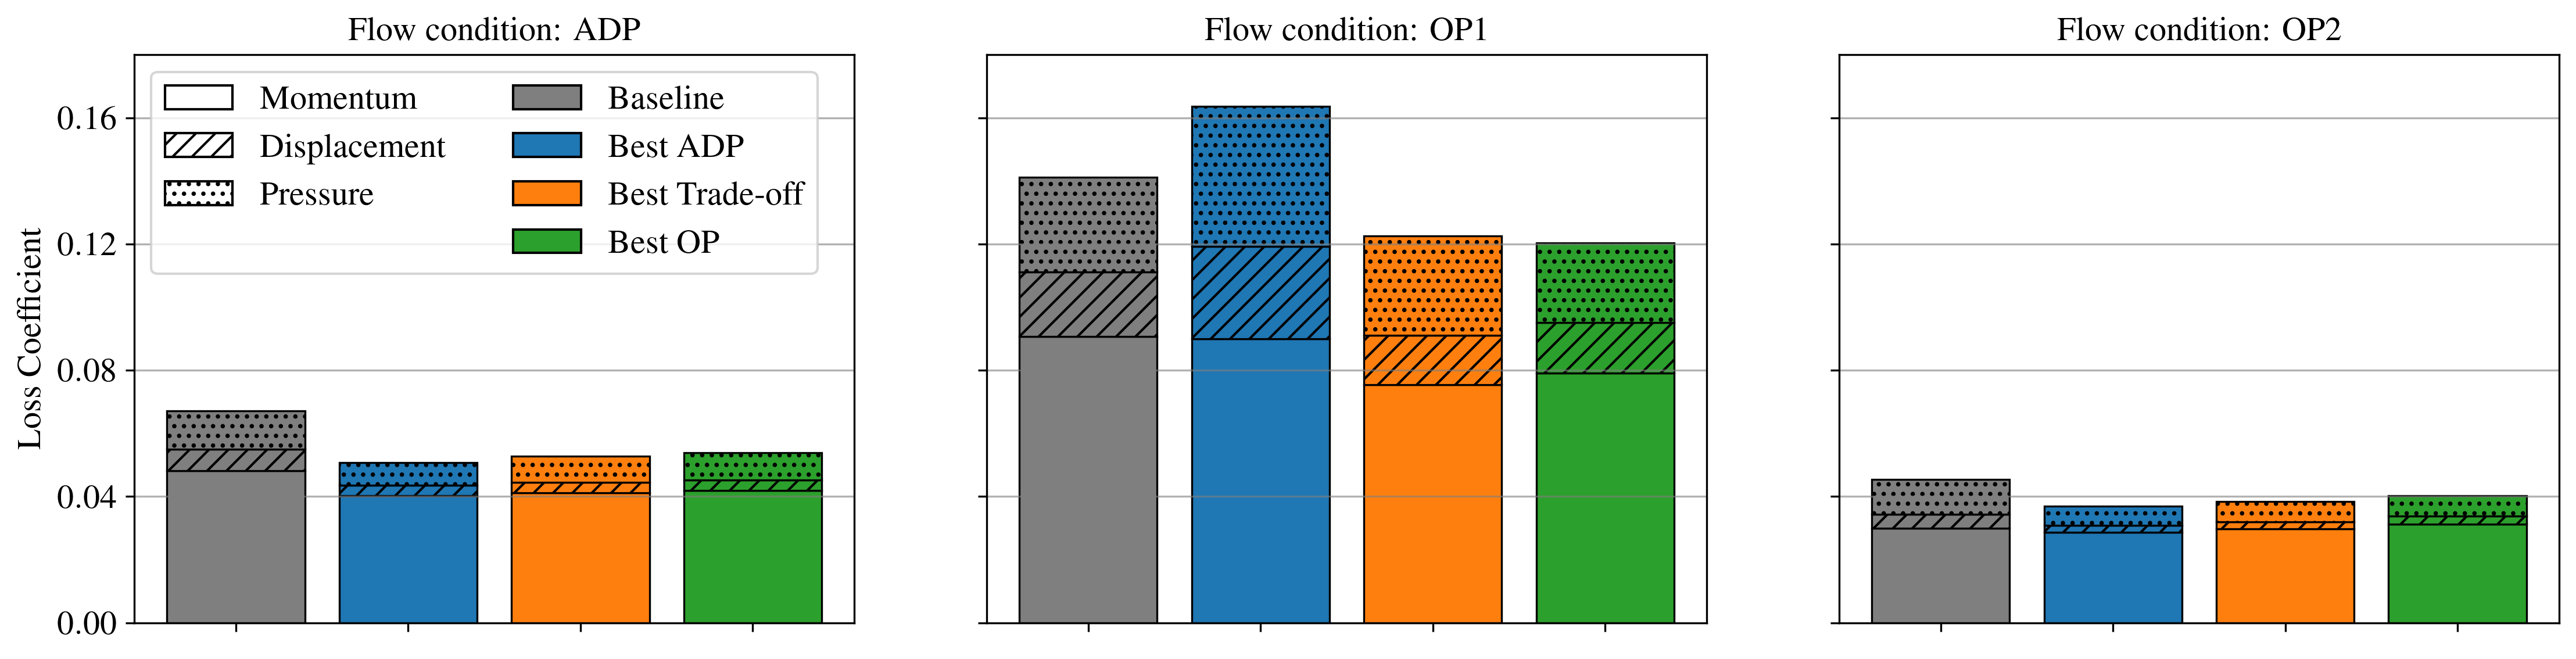

In [70]:
fs = 14

plt.rcParams.update({
    "figure.dpi": 300,
    "font.size": fs,
    'legend.fontsize': fs, 
    "axes.titlesize": fs,
    "axes.labelsize": fs
})

# Define design groups
design_groups = {
    'ADP': ['ADP_b', 'ADP_1', 'ADP_2', 'ADP_3'],
    'OP1': ['OP1_b', 'OP1_1', 'OP1_2', 'OP1_3'],
    'OP2': ['OP2_b', 'OP2_1', 'OP2_2', 'OP2_3']
}

# Define colors and hatches
colors = ['tab:grey', 'tab:blue', 'tab:orange', 'tab:green']
hatches = ['', '///', '...']  # No hatch for Momentum, diagonal for Displacement, dots for Pressure
design_labels = ['Baseline', 'Best ADP', 'Best Trade-off', 'Best OP']

# Calculate global y-axis limits
all_momentum = results['Momentum'].values
all_displacement = results['Displacement'].values
all_pressure = results['Pressure'].values
# Maximum stacked value
max_stack = np.max(all_momentum + all_displacement + all_pressure)
y_max = max_stack * 1.1  # Add 10% margin

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (group_name, designs) in enumerate(design_groups.items()):
    # Filter data for current design group
    group_data = results[results['Design'].isin(designs)].copy()
    group_data['Design'] = pd.Categorical(group_data['Design'], categories=designs, ordered=True)
    group_data = group_data.sort_values('Design')
    
    x_pos = range(len(designs))
    
    # Bottom layer: Momentum (no hatch)
    axes[idx].bar(x_pos, group_data['Momentum'], 
                  color=colors, edgecolor='black', linewidth=0.8,
                  hatch=hatches[0])
    
    # Middle layer: Displacement (diagonal hatch)
    axes[idx].bar(x_pos, group_data['Displacement'], 
                  bottom=group_data['Momentum'],
                  color=colors, edgecolor='black', linewidth=0.8,
                  hatch=hatches[1])
    
    # Top layer: Pressure (dots hatch)
    axes[idx].bar(x_pos, group_data['Pressure'], 
                  bottom=group_data['Momentum'] + group_data['Displacement'],
                  color=colors, edgecolor='black', linewidth=0.8,
                  hatch=hatches[2])
    
    axes[idx].set_xticks(x_pos)
    axes[idx].set_yticks([0,0.04,0.08,0.12,0.16])
    axes[idx].set_xticklabels([])
    axes[idx].set_title(f'Flow condition: {group_name}')
    axes[idx].set_ylim(0, y_max)
    axes[idx].grid(True, axis='y', color='tab:grey', alpha=0.6)
    if idx == 0:
        axes[idx].set_ylabel('Loss Coefficient')
    if idx>=1:
        axes[idx].set_yticklabels([])

# Create custom legend
from matplotlib.patches import Patch

# Legend handles
legend_handles = []

# First column: hatch patterns with white background
legend_handles.append(Patch(facecolor='white', edgecolor='black', hatch=hatches[0], label='Momentum'))
legend_handles.append(Patch(facecolor='white', edgecolor='black', hatch=hatches[1], label='Displacement'))
legend_handles.append(Patch(facecolor='white', edgecolor='black', hatch=hatches[2], label='Pressure'))
legend_handles.append(Patch(facecolor='none', edgecolor='none', label=''))  # Spacer

# Second column: colors for design conditions
for color, label in zip(colors, design_labels):
    legend_handles.append(Patch(facecolor=color, edgecolor='black', label=label))

# Add legend to the first subplot
axes[0].legend(handles=legend_handles, loc='upper left', ncol=2, frameon=True)

plt.tight_layout()

plt.savefig(os.path.join(os.getcwd(), "denton_losses.pdf"), bbox_inches="tight")